# Physics-Informed AI for Electrostatic Source Recovery



## Notebook Overview

This notebook demonstrates a synthetic inverse electrostatics problem using neural networks and differentiable physics.

The goal is to recover hidden point charge locations and charge magnitudes from boundary potential measurements. The workflow compares a supervised neural inverse solver, a physics-informed training strategy, and a hybrid neural + physics refinement method.


## 1. Imports and Setup

This section imports the scientific computing and deep learning libraries used in the project.


In [2]:
import random
import itertools
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float32)

print("Using device:", device)

Using device: cpu


## 2. Domain Definition and Differentiable Forward Model

This section defines the 2D simulation domain and the core electrostatic forward model. The forward model maps hidden source parameters to electric potential values on a grid.

Keeping this model differentiable allows it to be reused later for physics-informed training and optimization-based refinement.


In [3]:
@dataclass
class Domain:
    x_min: float = 0.0
    x_max: float = 10.0
    y_min: float = 0.0
    y_max: float = 10.0


domain = Domain()

# Use FAST_MODE=True for quick testing.
# Use FAST_MODE=False for stronger final results.
FAST_MODE = True

if FAST_MODE:
    grid_size = 50
    n_train = 2500
    n_test = 500
    supervised_epochs = 80
    physics_epochs = 40
else:
    grid_size = 80
    n_train = 10000
    n_test = 2000
    supervised_epochs = 250
    physics_epochs = 120

n_sources = 2
eps = 0.5
kernel = "softened_3d"

charge_range = (-5.0, 5.0)
position_margin = 1.0
noise_level = 0.01

print("FAST_MODE:", FAST_MODE)
print("grid_size:", grid_size)
print("n_train:", n_train)
print("n_test:", n_test)
print("n_sources:", n_sources)

FAST_MODE: True
grid_size: 50
n_train: 2500
n_test: 500
n_sources: 2


In [4]:
def make_grid(domain, grid_size, device=device):
    x = torch.linspace(domain.x_min, domain.x_max, grid_size, device=device)
    y = torch.linspace(domain.y_min, domain.y_max, grid_size, device=device)
    Y, X = torch.meshgrid(y, x, indexing="ij")
    return X, Y


def tensor_to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


X, Y = make_grid(domain, grid_size, device=device)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([50, 50])
Y shape: torch.Size([50, 50])


In [5]:
def calculate_potential(
    positions,
    charges,
    X,
    Y,
    eps=0.5,
    kernel="softened_3d",
):
    """
    Differentiable electrostatic potential model.

    positions: shape (n_sources, 2)
    charges: shape (n_sources,)
    """
    dx = X.unsqueeze(0) - positions[:, 0].view(-1, 1, 1)
    dy = Y.unsqueeze(0) - positions[:, 1].view(-1, 1, 1)

    r2 = dx**2 + dy**2 + eps**2

    if kernel == "softened_3d":
        V_sources = charges.view(-1, 1, 1) / torch.sqrt(r2)

    elif kernel == "log_2d":
        V_sources = charges.view(-1, 1, 1) * torch.log(torch.sqrt(r2))

    else:
        raise ValueError("Unknown kernel.")

    return V_sources.sum(dim=0)


def get_boundary(V):
    """
    Extract boundary values from a 2D potential field.
    """
    top = V[0, :]
    right = V[1:-1, -1]
    bottom = torch.flip(V[-1, :], dims=[0])
    left = torch.flip(V[1:-1, 0], dims=[0])

    return torch.cat([top, right, bottom, left])


def add_noise(x, noise_level=0.0, relative=True):
    if noise_level == 0.0:
        return x.clone()

    if relative:
        scale = torch.std(x)
        return x + noise_level * scale * torch.randn_like(x)

    return x + noise_level * torch.randn_like(x)


def relative_mse(pred, target, eps=1e-12):
    return torch.mean((pred - target) ** 2) / (torch.mean(target ** 2) + eps)

In [6]:
def pack_params(positions, charges):
    """
    Convert positions and charges to one vector.

    Output format:
    [x1, y1, x2, y2, ..., q1, q2, ...]
    """
    return torch.cat(
        [
            positions.reshape(-1),
            charges.reshape(-1),
        ]
    )


def unpack_params(params, n_sources):
    """
    Convert parameter vector back to positions and charges.

    params shape:
    (..., 3 * n_sources)
    """
    positions_flat = params[..., :2 * n_sources]
    charges = params[..., 2 * n_sources:]

    positions = positions_flat.reshape(*params.shape[:-1], n_sources, 2)

    return positions, charges


def sort_sources_by_x(positions, charges):
    """
    Sort sources by x coordinate to reduce label ambiguity.
    """
    idx = torch.argsort(positions[:, 0])
    return positions[idx], charges[idx]

In [7]:
def sample_random_sources(
    n_sources,
    domain,
    charge_range=(-5.0, 5.0),
    margin=1.0,
    min_distance=0.7,
    max_tries=100,
    device=device,
):
    """
    Generate random source positions and charges.
    Ensures sources are not too close to each other.
    """
    for _ in range(max_tries):
        x = domain.x_min + margin + (domain.x_max - domain.x_min - 2 * margin) * torch.rand(n_sources, device=device)
        y = domain.y_min + margin + (domain.y_max - domain.y_min - 2 * margin) * torch.rand(n_sources, device=device)

        positions = torch.stack([x, y], dim=1)

        valid = True

        for i in range(n_sources):
            for j in range(i + 1, n_sources):
                if torch.norm(positions[i] - positions[j]) < min_distance:
                    valid = False

        if valid:
            q_min, q_max = charge_range
            charges = q_min + (q_max - q_min) * torch.rand(n_sources, device=device)

            # Avoid extremely tiny charges.
            charges = torch.where(
                torch.abs(charges) < 0.5,
                torch.sign(charges + 1e-6) * 0.5,
                charges,
            )

            positions, charges = sort_sources_by_x(positions, charges)

            return positions, charges

    raise RuntimeError("Could not sample valid source positions.")


def generate_dataset(
    n_samples,
    n_sources,
    X,
    Y,
    domain,
    eps=0.5,
    kernel="softened_3d",
    charge_range=(-5.0, 5.0),
    margin=1.0,
    noise_level=0.0,
    device=device,
):
    """
    Generate synthetic supervised dataset.

    Input:
        boundary potential

    Target:
        source positions and charges
    """
    boundaries = []
    targets = []

    for i in range(n_samples):
        positions, charges = sample_random_sources(
            n_sources=n_sources,
            domain=domain,
            charge_range=charge_range,
            margin=margin,
            device=device,
        )

        V = calculate_potential(
            positions=positions,
            charges=charges,
            X=X,
            Y=Y,
            eps=eps,
            kernel=kernel,
        )

        boundary = get_boundary(V)

        if noise_level > 0:
            boundary = add_noise(boundary, noise_level=noise_level, relative=True)

        target = pack_params(positions, charges)

        boundaries.append(boundary)
        targets.append(target)

    boundaries = torch.stack(boundaries)
    targets = torch.stack(targets)

    return boundaries, targets

## 3. Synthetic Dataset Generation and Preprocessing

Random source configurations are generated inside the domain. For each configuration, the electric potential field is computed, and only the boundary potential values are used as model inputs.

The resulting dataset is then standardized and prepared for neural network training.


In [8]:
train_boundary_raw, train_params_raw = generate_dataset(
    n_samples=n_train,
    n_sources=n_sources,
    X=X,
    Y=Y,
    domain=domain,
    eps=eps,
    kernel=kernel,
    charge_range=charge_range,
    margin=position_margin,
    noise_level=noise_level,
    device=device,
)

test_boundary_raw, test_params_raw = generate_dataset(
    n_samples=n_test,
    n_sources=n_sources,
    X=X,
    Y=Y,
    domain=domain,
    eps=eps,
    kernel=kernel,
    charge_range=charge_range,
    margin=position_margin,
    noise_level=noise_level,
    device=device,
)

print("train_boundary_raw:", train_boundary_raw.shape)
print("train_params_raw:", train_params_raw.shape)
print("test_boundary_raw:", test_boundary_raw.shape)
print("test_params_raw:", test_params_raw.shape)

train_boundary_raw: torch.Size([2500, 196])
train_params_raw: torch.Size([2500, 6])
test_boundary_raw: torch.Size([500, 196])
test_params_raw: torch.Size([500, 6])


In [9]:
class StandardScalerTorch:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True)
        self.std = torch.where(self.std < 1e-8, torch.ones_like(self.std), self.std)

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse_transform(self, x):
        return x * self.std + self.mean


boundary_scaler = StandardScalerTorch()
target_scaler = StandardScalerTorch()

boundary_scaler.fit(train_boundary_raw)
target_scaler.fit(train_params_raw)

train_boundary = boundary_scaler.transform(train_boundary_raw)
test_boundary = boundary_scaler.transform(test_boundary_raw)

train_params = target_scaler.transform(train_params_raw)
test_params = target_scaler.transform(test_params_raw)

print("Normalized train boundary mean:", train_boundary.mean().item())
print("Normalized train boundary std:", train_boundary.std().item())

Normalized train boundary mean: -3.3475913707725624e-10
Normalized train boundary std: 0.999800980091095


In [10]:
batch_size = 128

train_dataset = TensorDataset(
    train_boundary,
    train_params,
    train_boundary_raw,
    train_params_raw,
)

test_dataset = TensorDataset(
    test_boundary,
    test_params,
    test_boundary_raw,
    test_params_raw,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

input_dim = train_boundary.shape[1]
output_dim = train_params.shape[1]

print("input_dim:", input_dim)
print("output_dim:", output_dim)

input_dim: 196
output_dim: 6


## 4. Supervised Neural Inverse Solver

A multilayer perceptron is trained to predict source positions and charge magnitudes directly from boundary measurements.

This provides a fast approximate inverse mapping from boundary potential values to hidden source parameters.


In [11]:
class BoundaryToSourcesMLP(torch.nn.Module):
    """
    Neural inverse solver:

    boundary potential -> source positions and charges
    """
    def __init__(self, input_dim, output_dim, hidden_dim=256, dropout=0.05):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),

            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),

            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.GELU(),

            torch.nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


supervised_model = BoundaryToSourcesMLP(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dim=256,
    dropout=0.05,
).to(device)

print(supervised_model)

BoundaryToSourcesMLP(
  (net): Sequential(
    (0): Linear(in_features=196, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [12]:
def train_supervised_model(
    model,
    train_loader,
    test_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    loss_fn = torch.nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for boundary_scaled, params_scaled, boundary_raw, params_raw in train_loader:
            pred_scaled = model(boundary_scaled)
            loss = loss_fn(pred_scaled, params_scaled)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))

        model.eval()
        test_batch_losses = []

        with torch.no_grad():
            for boundary_scaled, params_scaled, boundary_raw, params_raw in test_loader:
                pred_scaled = model(boundary_scaled)
                loss = loss_fn(pred_scaled, params_scaled)
                test_batch_losses.append(loss.item())

        test_loss = float(np.mean(test_batch_losses))

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:04d} | "
                f"train loss = {train_loss:.6e} | "
                f"test loss = {test_loss:.6e}"
            )

    return train_losses, test_losses

In [13]:
supervised_train_losses, supervised_test_losses = train_supervised_model(
    model=supervised_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=supervised_epochs,
    lr=1e-3,
    weight_decay=1e-5,
)

Epoch 0000 | train loss = 5.931654e-01 | test loss = 4.881449e-01
Epoch 0010 | train loss = 2.854753e-01 | test loss = 3.134435e-01
Epoch 0020 | train loss = 2.313113e-01 | test loss = 2.506891e-01
Epoch 0030 | train loss = 2.056703e-01 | test loss = 2.494643e-01
Epoch 0040 | train loss = 1.860279e-01 | test loss = 2.492089e-01
Epoch 0050 | train loss = 1.656589e-01 | test loss = 2.143123e-01
Epoch 0060 | train loss = 1.557878e-01 | test loss = 2.238521e-01
Epoch 0070 | train loss = 1.420955e-01 | test loss = 1.909359e-01
Epoch 0079 | train loss = 1.355535e-01 | test loss = 1.994266e-01


### Supervised Training Curve

The following plot shows the supervised training and test loss over epochs.


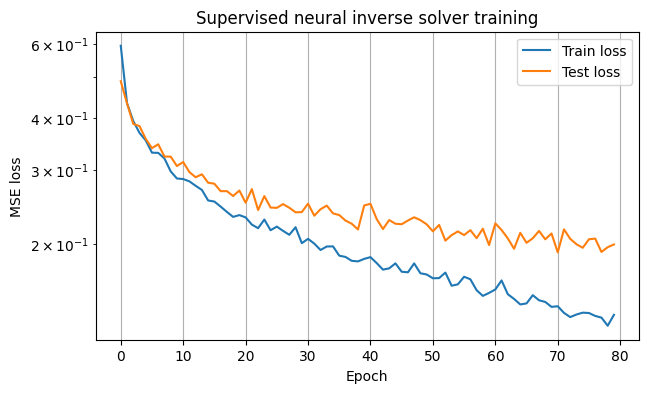

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(supervised_train_losses, label="Train loss")
plt.plot(supervised_test_losses, label="Test loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Supervised neural inverse solver training")
plt.grid(True)
plt.legend()
plt.show()

### Evaluation Metrics

Because the two sources are unordered, predicted sources must be matched to the true sources before computing errors. This avoids penalizing the model for label swapping between identical source slots.


In [15]:
def match_sources(true_positions, true_charges, pred_positions, pred_charges):
    """
    Match predicted sources to true sources using minimum total position error.
    """
    true_positions_np = tensor_to_numpy(true_positions)
    true_charges_np = tensor_to_numpy(true_charges)
    pred_positions_np = tensor_to_numpy(pred_positions)
    pred_charges_np = tensor_to_numpy(pred_charges)

    n_true = len(true_positions_np)
    n_pred = len(pred_positions_np)

    if n_true != n_pred:
        raise ValueError("Number of true and predicted sources must match.")

    best_perm = None
    best_error = np.inf

    for perm in itertools.permutations(range(n_pred)):
        total_error = 0.0

        for i_true, i_pred in enumerate(perm):
            total_error += np.linalg.norm(true_positions_np[i_true] - pred_positions_np[i_pred])

        if total_error < best_error:
            best_error = total_error
            best_perm = perm

    matched_positions = pred_positions_np[list(best_perm)]
    matched_charges = pred_charges_np[list(best_perm)]

    position_errors = np.linalg.norm(true_positions_np - matched_positions, axis=1)
    charge_errors = np.abs(true_charges_np - matched_charges)

    return {
        "mean_position_error": float(np.mean(position_errors)),
        "mean_charge_error": float(np.mean(charge_errors)),
        "position_errors": position_errors,
        "charge_errors": charge_errors,
        "matched_positions": matched_positions,
        "matched_charges": matched_charges,
    }


def evaluate_parameter_predictions(
    pred_params_raw,
    true_params_raw,
    n_sources,
):
    position_errors = []
    charge_errors = []

    for i in range(pred_params_raw.shape[0]):
        pred_positions, pred_charges = unpack_params(pred_params_raw[i], n_sources)
        true_positions, true_charges = unpack_params(true_params_raw[i], n_sources)

        match = match_sources(
            true_positions=true_positions,
            true_charges=true_charges,
            pred_positions=pred_positions,
            pred_charges=pred_charges,
        )

        position_errors.append(match["mean_position_error"])
        charge_errors.append(match["mean_charge_error"])

    return {
        "mean_position_error": float(np.mean(position_errors)),
        "std_position_error": float(np.std(position_errors)),
        "mean_charge_error": float(np.mean(charge_errors)),
        "std_charge_error": float(np.std(charge_errors)),
    }

In [16]:
supervised_model.eval()

with torch.no_grad():
    pred_test_scaled = supervised_model(test_boundary)
    pred_test_raw = target_scaler.inverse_transform(pred_test_scaled)

supervised_metrics = evaluate_parameter_predictions(
    pred_params_raw=pred_test_raw,
    true_params_raw=test_params_raw,
    n_sources=n_sources,
)

print("Supervised neural inverse solver metrics")
print("-" * 60)

for key, value in supervised_metrics.items():
    print(f"{key}: {value:.6f}")

Supervised neural inverse solver metrics
------------------------------------------------------------
mean_position_error: 0.980661
std_position_error: 0.574173
mean_charge_error: 0.919550
std_charge_error: 0.682019


In [17]:
def plot_field(V, title="Potential field", domain=domain, cmap="viridis"):
    plt.figure(figsize=(6, 5))
    plt.imshow(
        tensor_to_numpy(V),
        origin="lower",
        extent=[domain.x_min, domain.x_max, domain.y_min, domain.y_max],
        aspect="equal",
        cmap=cmap,
    )
    plt.colorbar(label="Potential")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()


def plot_sources(true_positions, pred_positions=None, title="Source positions", domain=domain):
    true_np = tensor_to_numpy(true_positions)

    plt.figure(figsize=(6, 6))
    plt.scatter(true_np[:, 0], true_np[:, 1], marker="o", s=140, label="True sources")

    if pred_positions is not None:
        pred_np = tensor_to_numpy(pred_positions)
        plt.scatter(pred_np[:, 0], pred_np[:, 1], marker="x", s=160, label="Predicted sources")

    plt.xlim(domain.x_min, domain.x_max)
    plt.ylim(domain.y_min, domain.y_max)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()


def show_single_prediction(model, sample_index=0):
    model.eval()

    boundary_scaled = test_boundary[sample_index:sample_index + 1]
    true_params = test_params_raw[sample_index]

    with torch.no_grad():
        pred_scaled = model(boundary_scaled)
        pred_raw = target_scaler.inverse_transform(pred_scaled)[0]

    true_positions, true_charges = unpack_params(true_params, n_sources)
    pred_positions, pred_charges = unpack_params(pred_raw, n_sources)

    V_true = calculate_potential(
        positions=true_positions,
        charges=true_charges,
        X=X,
        Y=Y,
        eps=eps,
        kernel=kernel,
    )

    V_pred = calculate_potential(
        positions=pred_positions,
        charges=pred_charges,
        X=X,
        Y=Y,
        eps=eps,
        kernel=kernel,
    )

    print("True charges:", tensor_to_numpy(true_charges))
    print("Predicted charges:", tensor_to_numpy(pred_charges))

    match = match_sources(
        true_positions=true_positions,
        true_charges=true_charges,
        pred_positions=pred_positions,
        pred_charges=pred_charges,
    )

    print("Mean position error:", match["mean_position_error"])
    print("Mean charge error:", match["mean_charge_error"])

    plot_sources(
        true_positions=true_positions,
        pred_positions=pred_positions,
        title="Neural network prediction",
        domain=domain,
    )

    plot_field(V_true, title="True potential", domain=domain)
    plot_field(V_pred, title="Predicted potential from NN output", domain=domain)
    plot_field(torch.abs(V_true - V_pred), title="Absolute potential error", domain=domain, cmap="magma")

### Supervised Prediction Example

The following visualization compares the true source configuration with the supervised model prediction for one test sample.


True charges: [-4.1926427 -4.23571  ]
Predicted charges: [-3.3134284 -4.5213017]
Mean position error: 0.4113730788230896
Mean charge error: 0.5824029445648193


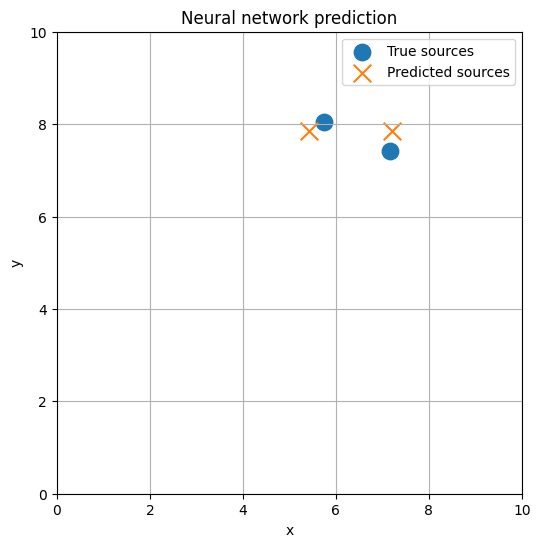

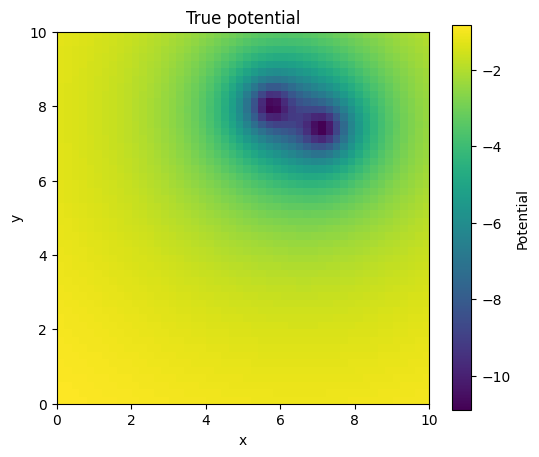

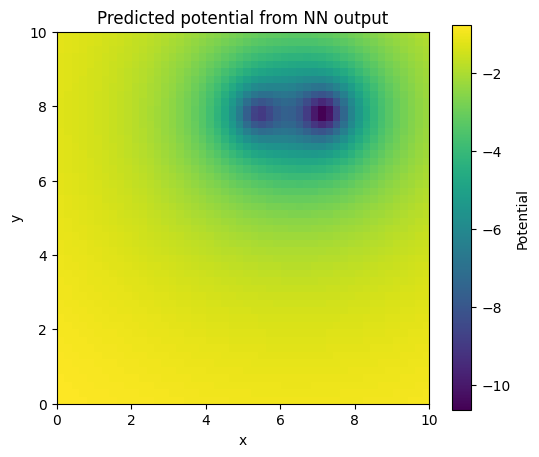

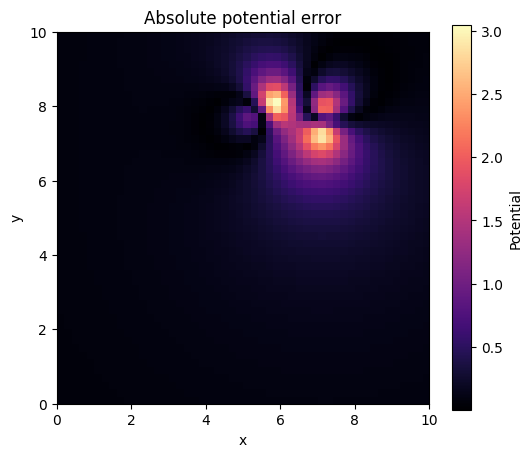

In [18]:
show_single_prediction(
    model=supervised_model,
    sample_index=0,
)

## 5. Physics-Informed Training

The supervised model is refined using a physics-consistency loss. Predicted source parameters are passed through the differentiable forward model, and the reconstructed boundary potential is compared with the observed boundary potential.

This encourages predictions that are not only close to the labeled parameters, but also consistent with the underlying physical model.


In [19]:
def physics_consistency_loss_batch(
    pred_params_raw,
    boundary_target_raw,
    X,
    Y,
    n_sources,
    eps=0.5,
    kernel="softened_3d",
):
    """
    Compute physics consistency loss.

    The network predicts source parameters.
    We reconstruct boundary potential from those parameters.
    Then compare it with the measured boundary.
    """
    batch_size = pred_params_raw.shape[0]
    losses = []

    for i in range(batch_size):
        pred_positions, pred_charges = unpack_params(pred_params_raw[i], n_sources)

        V_pred = calculate_potential(
            positions=pred_positions,
            charges=pred_charges,
            X=X,
            Y=Y,
            eps=eps,
            kernel=kernel,
        )

        boundary_pred = get_boundary(V_pred)

        loss_i = relative_mse(boundary_pred, boundary_target_raw[i])
        losses.append(loss_i)

    return torch.stack(losses).mean()

In [20]:
physics_model = BoundaryToSourcesMLP(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_dim=256,
    dropout=0.05,
).to(device)

# Start from supervised weights. This is usually much more stable.
physics_model.load_state_dict(supervised_model.state_dict())

print("Physics-informed model initialized from supervised model.")

Physics-informed model initialized from supervised model.


In [21]:
def train_physics_informed_model(
    model,
    train_loader,
    test_loader,
    target_scaler,
    X,
    Y,
    n_sources,
    epochs=50,
    lr=3e-4,
    alpha_supervised=1.0,
    beta_physics=0.1,
    eps=0.5,
    kernel="softened_3d",
):
    """
    Train model using both supervised loss and physics consistency loss.

    total loss = alpha * supervised parameter loss + beta * physics boundary reconstruction loss
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    supervised_loss_fn = torch.nn.MSELoss()

    train_total_losses = []
    train_supervised_losses = []
    train_physics_losses = []
    test_param_losses = []

    for epoch in range(epochs):
        model.train()

        epoch_total = []
        epoch_supervised = []
        epoch_physics = []

        for boundary_scaled, params_scaled, boundary_raw, params_raw in train_loader:
            pred_scaled = model(boundary_scaled)
            pred_raw = target_scaler.inverse_transform(pred_scaled)

            supervised_loss = supervised_loss_fn(pred_scaled, params_scaled)

            physics_loss = physics_consistency_loss_batch(
                pred_params_raw=pred_raw,
                boundary_target_raw=boundary_raw,
                X=X,
                Y=Y,
                n_sources=n_sources,
                eps=eps,
                kernel=kernel,
            )

            total_loss = alpha_supervised * supervised_loss + beta_physics * physics_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_total.append(total_loss.item())
            epoch_supervised.append(supervised_loss.item())
            epoch_physics.append(physics_loss.item())

        model.eval()
        test_losses = []

        with torch.no_grad():
            for boundary_scaled, params_scaled, boundary_raw, params_raw in test_loader:
                pred_scaled = model(boundary_scaled)
                loss = supervised_loss_fn(pred_scaled, params_scaled)
                test_losses.append(loss.item())

        train_total_losses.append(float(np.mean(epoch_total)))
        train_supervised_losses.append(float(np.mean(epoch_supervised)))
        train_physics_losses.append(float(np.mean(epoch_physics)))
        test_param_losses.append(float(np.mean(test_losses)))

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:04d} | "
                f"total = {train_total_losses[-1]:.6e} | "
                f"supervised = {train_supervised_losses[-1]:.6e} | "
                f"physics = {train_physics_losses[-1]:.6e} | "
                f"test param = {test_param_losses[-1]:.6e}"
            )

    return {
        "total": train_total_losses,
        "supervised": train_supervised_losses,
        "physics": train_physics_losses,
        "test_param": test_param_losses,
    }

In [22]:
physics_history = train_physics_informed_model(
    model=physics_model,
    train_loader=train_loader,
    test_loader=test_loader,
    target_scaler=target_scaler,
    X=X,
    Y=Y,
    n_sources=n_sources,
    epochs=physics_epochs,
    lr=3e-4,
    alpha_supervised=1.0,
    beta_physics=0.1,
    eps=eps,
    kernel=kernel,
)

Epoch 0000 | total = 1.360190e-01 | supervised = 1.201146e-01 | physics = 1.590440e-01 | test param = 1.805559e-01
Epoch 0010 | total = 1.087735e-01 | supervised = 9.978660e-02 | physics = 8.986866e-02 | test param = 1.784780e-01
Epoch 0020 | total = 1.034780e-01 | supervised = 9.580416e-02 | physics = 7.673805e-02 | test param = 1.760993e-01
Epoch 0030 | total = 1.033594e-01 | supervised = 9.649275e-02 | physics = 6.866622e-02 | test param = 1.722826e-01
Epoch 0039 | total = 9.872772e-02 | supervised = 9.196476e-02 | physics = 6.762958e-02 | test param = 1.736904e-01


### Physics-Informed Training Curves

The following plot tracks the total loss, supervised loss, physics loss, and test loss during physics-informed training.


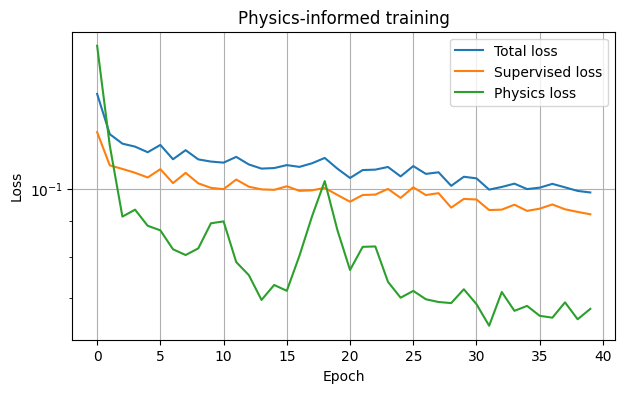

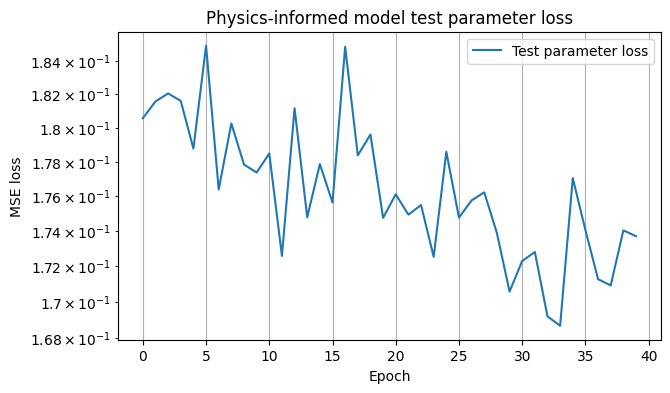

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(physics_history["total"], label="Total loss")
plt.plot(physics_history["supervised"], label="Supervised loss")
plt.plot(physics_history["physics"], label="Physics loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Physics-informed training")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(physics_history["test_param"], label="Test parameter loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Physics-informed model test parameter loss")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
physics_model.eval()

with torch.no_grad():
    physics_pred_test_scaled = physics_model(test_boundary)
    physics_pred_test_raw = target_scaler.inverse_transform(physics_pred_test_scaled)

physics_metrics = evaluate_parameter_predictions(
    pred_params_raw=physics_pred_test_raw,
    true_params_raw=test_params_raw,
    n_sources=n_sources,
)

print("Physics-informed neural inverse solver metrics")
print("-" * 60)

for key, value in physics_metrics.items():
    print(f"{key}: {value:.6f}")

Physics-informed neural inverse solver metrics
------------------------------------------------------------
mean_position_error: 0.883558
std_position_error: 0.563761
mean_charge_error: 0.836813
std_charge_error: 0.665256


### Physics-Informed Prediction Example

The following visualization shows the prediction from the physics-informed model on a test sample.


True charges: [-4.1926427 -4.23571  ]
Predicted charges: [-3.7297993 -4.0430984]
Mean position error: 0.3541630506515503
Mean charge error: 0.3277275562286377


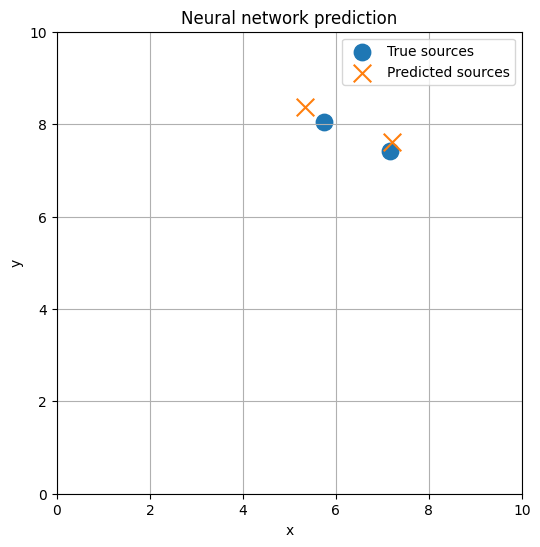

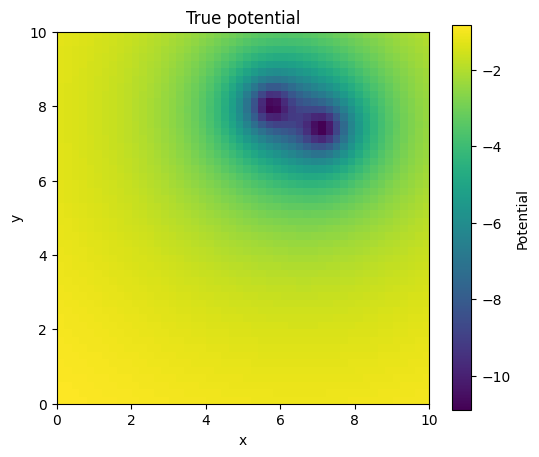

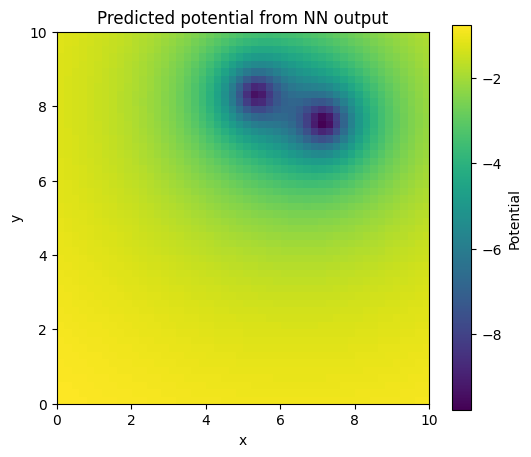

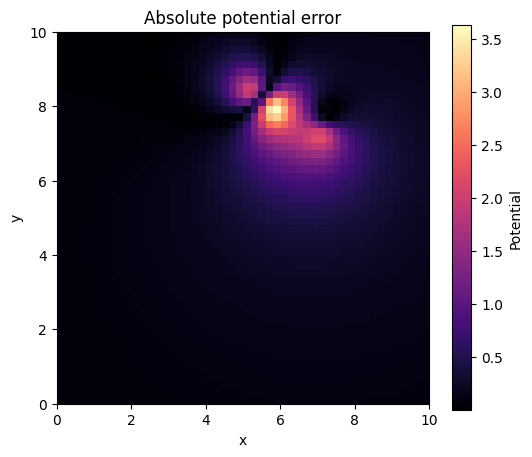

In [25]:
show_single_prediction(
    model=physics_model,
    sample_index=0,
)

## 6. Hybrid Neural + Physics-Based Refinement

The trained neural network provides a fast initial prediction. This prediction is then refined using gradient-based optimization through the physical forward model.

This hybrid approach combines neural inference speed with the accuracy of direct physics-based optimization.


In [26]:
def clamp_positions_(positions, domain, margin=0.15):
    with torch.no_grad():
        positions[:, 0].clamp_(domain.x_min + margin, domain.x_max - margin)
        positions[:, 1].clamp_(domain.y_min + margin, domain.y_max - margin)


def refine_prediction_with_physics(
    initial_params_raw,
    boundary_target_raw,
    X,
    Y,
    domain,
    n_sources,
    eps=0.5,
    kernel="softened_3d",
    steps=400,
    lr_pos=0.03,
    lr_q=0.02,
    verbose=False,
):
    """
    Hybrid solver:

    1. Neural network predicts initial source parameters.
    2. Physics-based gradient optimization refines them.
    """
    init_positions, init_charges = unpack_params(initial_params_raw, n_sources)

    positions = init_positions.clone().detach().requires_grad_(True)
    charges = init_charges.clone().detach().requires_grad_(True)

    optimizer = torch.optim.Adam(
        [
            {"params": [positions], "lr": lr_pos},
            {"params": [charges], "lr": lr_q},
        ]
    )

    loss_history = []

    for step in range(steps):
        optimizer.zero_grad()

        V_pred = calculate_potential(
            positions=positions,
            charges=charges,
            X=X,
            Y=Y,
            eps=eps,
            kernel=kernel,
        )

        boundary_pred = get_boundary(V_pred)
        loss = relative_mse(boundary_pred, boundary_target_raw)

        loss.backward()
        optimizer.step()

        clamp_positions_(positions, domain)

        loss_history.append(loss.item())

        if verbose and step % 100 == 0:
            print(f"Step {step:04d} | loss = {loss.item():.6e}")

    refined_params = pack_params(
        positions.detach(),
        charges.detach(),
    )

    return refined_params, loss_history

In [27]:
def evaluate_hybrid_method(
    model,
    test_boundary_scaled,
    test_boundary_raw,
    test_params_raw,
    target_scaler,
    X,
    Y,
    domain,
    n_sources,
    n_eval=100,
    steps=400,
    eps=0.5,
    kernel="softened_3d",
):
    model.eval()

    n_eval = min(n_eval, test_boundary_scaled.shape[0])

    hybrid_preds = []
    nn_preds = []
    true_params_list = []

    with torch.no_grad():
        pred_scaled_all = model(test_boundary_scaled[:n_eval])
        pred_raw_all = target_scaler.inverse_transform(pred_scaled_all)

    for i in range(n_eval):
        refined_params, loss_history = refine_prediction_with_physics(
            initial_params_raw=pred_raw_all[i],
            boundary_target_raw=test_boundary_raw[i],
            X=X,
            Y=Y,
            domain=domain,
            n_sources=n_sources,
            eps=eps,
            kernel=kernel,
            steps=steps,
            verbose=False,
        )

        nn_preds.append(pred_raw_all[i])
        hybrid_preds.append(refined_params)
        true_params_list.append(test_params_raw[i])

        if i % 20 == 0:
            print(f"Refined {i}/{n_eval}")

    nn_preds = torch.stack(nn_preds)
    hybrid_preds = torch.stack(hybrid_preds)
    true_params_tensor = torch.stack(true_params_list)

    nn_metrics = evaluate_parameter_predictions(
        pred_params_raw=nn_preds,
        true_params_raw=true_params_tensor,
        n_sources=n_sources,
    )

    hybrid_metrics = evaluate_parameter_predictions(
        pred_params_raw=hybrid_preds,
        true_params_raw=true_params_tensor,
        n_sources=n_sources,
    )

    return nn_metrics, hybrid_metrics, nn_preds, hybrid_preds, true_params_tensor

In [28]:
hybrid_eval_count = 50 if FAST_MODE else 200
hybrid_steps = 250 if FAST_MODE else 600

nn_metrics_before_refinement, hybrid_metrics, nn_preds_eval, hybrid_preds_eval, true_params_eval = evaluate_hybrid_method(
    model=physics_model,
    test_boundary_scaled=test_boundary,
    test_boundary_raw=test_boundary_raw,
    test_params_raw=test_params_raw,
    target_scaler=target_scaler,
    X=X,
    Y=Y,
    domain=domain,
    n_sources=n_sources,
    n_eval=hybrid_eval_count,
    steps=hybrid_steps,
    eps=eps,
    kernel=kernel,
)

print("Neural prediction before refinement")
print("-" * 60)
for key, value in nn_metrics_before_refinement.items():
    print(f"{key}: {value:.6f}")

print("\nHybrid prediction after physics refinement")
print("-" * 60)
for key, value in hybrid_metrics.items():
    print(f"{key}: {value:.6f}")

Refined 0/50
Refined 20/50
Refined 40/50
Neural prediction before refinement
------------------------------------------------------------
mean_position_error: 0.930585
std_position_error: 0.476226
mean_charge_error: 1.115305
std_charge_error: 0.996350

Hybrid prediction after physics refinement
------------------------------------------------------------
mean_position_error: 0.516490
std_position_error: 0.699052
mean_charge_error: 0.632366
std_charge_error: 0.740931


## 7. Results and Method Comparison

The methods are compared using mean position error and mean charge error. The hybrid neural + physics refinement method achieves the best overall recovery accuracy in this experiment.


In [29]:
results_table = pd.DataFrame(
    [
        {
            "method": "Supervised MLP",
            **supervised_metrics,
        },
        {
            "method": "Physics-informed MLP",
            **physics_metrics,
        },
        {
            "method": "Physics-informed MLP before refinement",
            **nn_metrics_before_refinement,
        },
        {
            "method": "Hybrid MLP + physics refinement",
            **hybrid_metrics,
        },
    ]
)

display(results_table)

,method,mean_position_error,std_position_error,mean_charge_error,std_charge_error
0,Supervised MLP,0.980661,0.574173,0.919550,0.682019
1,Physics-informed MLP,0.883558,0.563761,0.836813,0.665256
2,Physics-informed MLP before refinement,0.930585,0.476226,1.115305,0.996350
3,Hybrid MLP + physics refinement,0.516490,0.699052,0.632366,0.740931


### Error Comparison Plot

The following plots compare the mean position error and mean charge error across the evaluated methods.


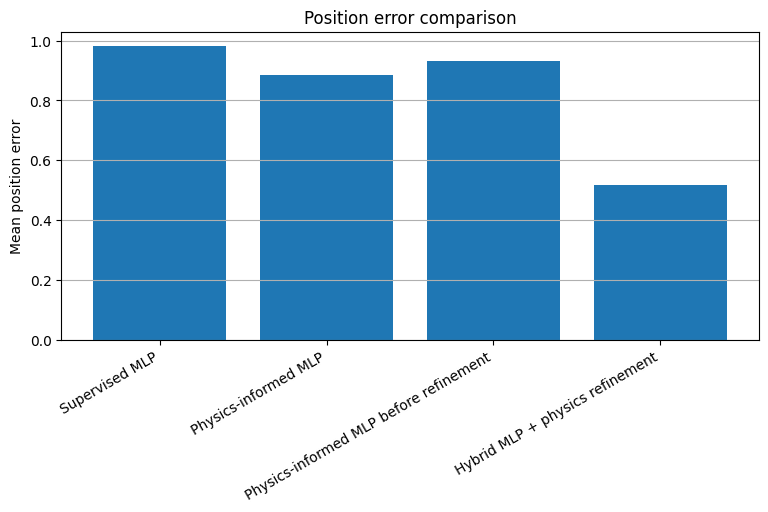

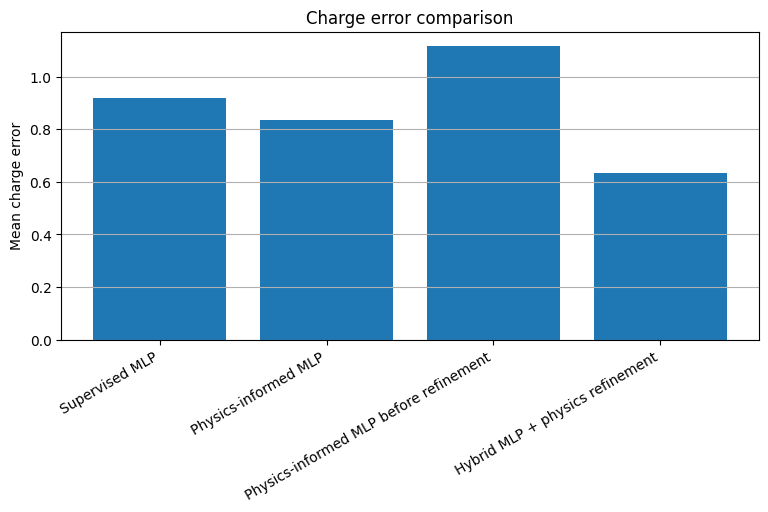

In [30]:
plt.figure(figsize=(9, 4))
plt.bar(
    results_table["method"],
    results_table["mean_position_error"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean position error")
plt.title("Position error comparison")
plt.grid(axis="y")
plt.show()


plt.figure(figsize=(9, 4))
plt.bar(
    results_table["method"],
    results_table["mean_charge_error"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean charge error")
plt.title("Charge error comparison")
plt.grid(axis="y")
plt.show()

### Hybrid Refinement Example

This example shows how physics-based refinement improves the neural network prediction for a single test sample.


True charges: [-4.1926427 -4.23571  ]
NN charges: [-3.7297988 -4.0431   ]
Hybrid charges: [-4.088592 -4.344454]


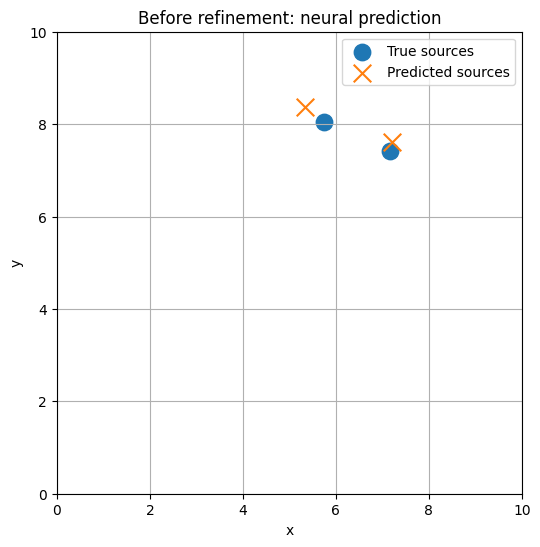

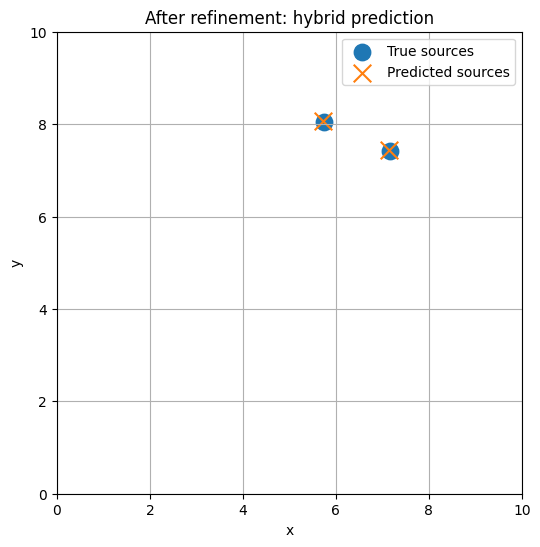

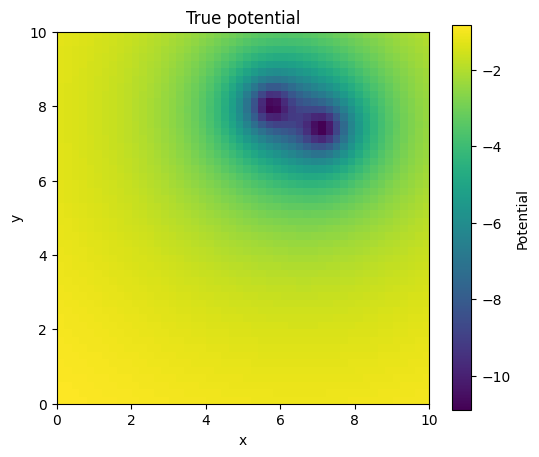

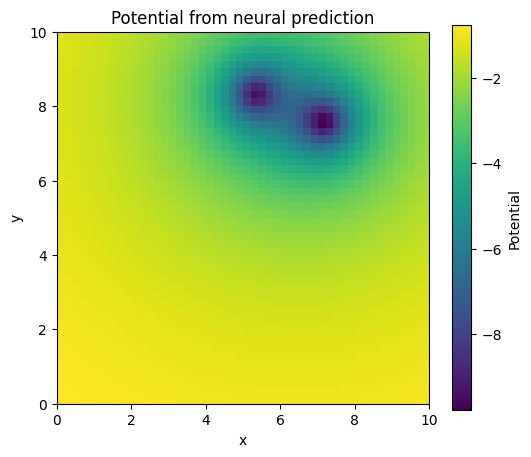

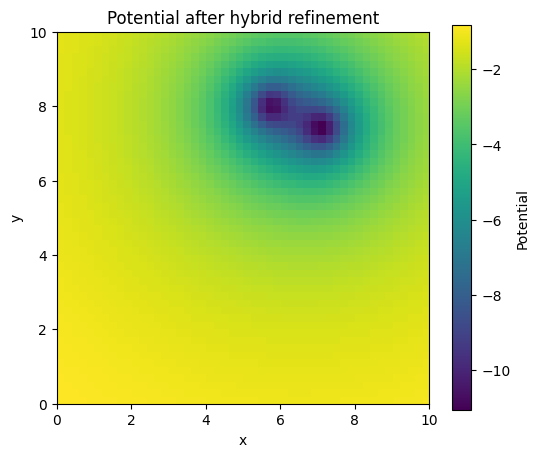

In [31]:
sample_index = 0

true_params = true_params_eval[sample_index]
nn_params = nn_preds_eval[sample_index]
hybrid_params = hybrid_preds_eval[sample_index]

true_positions, true_charges = unpack_params(true_params, n_sources)
nn_positions, nn_charges = unpack_params(nn_params, n_sources)
hybrid_positions, hybrid_charges = unpack_params(hybrid_params, n_sources)

print("True charges:", tensor_to_numpy(true_charges))
print("NN charges:", tensor_to_numpy(nn_charges))
print("Hybrid charges:", tensor_to_numpy(hybrid_charges))

plot_sources(
    true_positions=true_positions,
    pred_positions=nn_positions,
    title="Before refinement: neural prediction",
    domain=domain,
)

plot_sources(
    true_positions=true_positions,
    pred_positions=hybrid_positions,
    title="After refinement: hybrid prediction",
    domain=domain,
)

V_true = calculate_potential(true_positions, true_charges, X, Y, eps=eps, kernel=kernel)
V_nn = calculate_potential(nn_positions, nn_charges, X, Y, eps=eps, kernel=kernel)
V_hybrid = calculate_potential(hybrid_positions, hybrid_charges, X, Y, eps=eps, kernel=kernel)

plot_field(V_true, title="True potential", domain=domain)
plot_field(V_nn, title="Potential from neural prediction", domain=domain)
plot_field(V_hybrid, title="Potential after hybrid refinement", domain=domain)

## 8. Saving the Model

The trained supervised model and normalization parameters are saved for possible reuse.


In [32]:
torch.save(
    {
        "model_state_dict": supervised_model.state_dict(),
        "input_dim": input_dim,
        "output_dim": output_dim,
        "n_sources": n_sources,
        "grid_size": grid_size,
        "eps": eps,
        "kernel": kernel,
    },
    "supervised_inverse_solver.pt",
)

torch.save(
    {
        "model_state_dict": physics_model.state_dict(),
        "input_dim": input_dim,
        "output_dim": output_dim,
        "n_sources": n_sources,
        "grid_size": grid_size,
        "eps": eps,
        "kernel": kernel,
    },
    "physics_informed_inverse_solver.pt",
)

results_table.to_csv("ai_inverse_solver_results.csv", index=False)

print("Saved:")
print("- supervised_inverse_solver.pt")
print("- physics_informed_inverse_solver.pt")
print("- ai_inverse_solver_results.csv")

Saved:
- supervised_inverse_solver.pt
- physics_informed_inverse_solver.pt
- ai_inverse_solver_results.csv


## Limitations and Future Work

This notebook uses a synthetic 2D electrostatics setup with a known number of softened point charges. It does not model real radiation transport, clinical dosimetry, or a medical imaging system.

Future extensions could test sparse boundary measurements, more realistic noise models, variable source counts, and simplified radiotherapy-inspired inverse dose reconstruction problems.
